## Feature Selection - information gain - mutual information in regression problem statements

Estimate mutual information for a continuous target variable. 

Mutual information between two random variables is a non-negative value, which measures the dependancy between the variables. It is aqual to zero if and only if two random variables are independent, and higher values mean higher dependency. 

The function relies on nonparametric methods based on entropy estimation from k-nearest neighbors distances. 

Mutual information is calculated between two variables and measures the reduction in uncertainty for one variable given a known value of the other variable. 

Inshort: 

A quantity called mutual information measures the amount of information one can obtain from one random variable given another 

The mutual information between two random variables X and Y can be stated formally as follows:

I(X ; Y) = H(X) – H(X | Y) Where I(X ; Y) is the mutual information for X and Y, H(X) is the entropy for X and H(X | Y) is the conditional entropy for X given Y. The result has the units of bits.

In [3]:
import pandas as pd 
df = pd.read_csv("train(1).csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [13]:
numeric_list=['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numerical_cols = list(df.select_dtypes(include=numeric_list).columns)

In [15]:
df = df[numerical_cols]

In [17]:
df = df.drop("Id", axis=1)

In [23]:
### It is always a good practice to split train and test data to avoid
#overfitting
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(labels=['SalePrice'], axis=1),
    df['SalePrice'],
    test_size=0.3,
    random_state=0)

In [25]:
X_train.isnull().sum()

MSSubClass         0
LotFrontage      189
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         5
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       54
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
dtype: int64

In [27]:
from sklearn.feature_selection import mutual_info_regression
mutual_info = mutual_info_regression(X_train.fillna(0), y_train)
mutual_info

array([0.25720669, 0.21036228, 0.16619775, 0.53726992, 0.10088587,
       0.3495773 , 0.24798144, 0.10233148, 0.16373215, 0.        ,
       0.11286518, 0.38439323, 0.31120862, 0.23819312, 0.00085634,
       0.47973515, 0.01939466, 0.        , 0.2722969 , 0.08507693,
       0.04812114, 0.0222786 , 0.18440493, 0.18857119, 0.26705941,
       0.37656777, 0.36924222, 0.06550137, 0.17665984, 0.00794677,
       0.00459288, 0.01366238, 0.        , 0.00510056, 0.        ,
       0.00234327])

<Axes: >

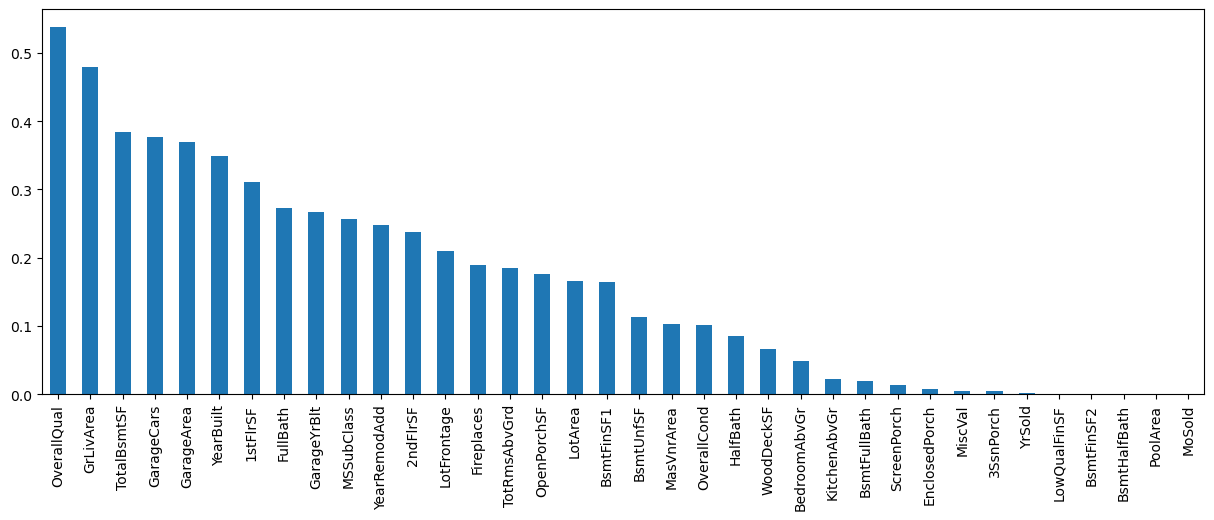

In [29]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False).plot.bar(figsize=(15,5))

In [31]:
from sklearn.feature_selection import SelectPercentile

1. SelectKBest

Sen tam olarak kaç tane feature istiyorsan (örneğin en iyi 5 tanesi), SelectKBest kullanıyorsun.

Yani k sayısını önceden belirtiyorsun.

Sınıflandırmada (mutual_info_classif) çoğu zaman “en iyi birkaç feature” seçmek mantıklı olduğu için genelde SelectKBest örneklerde gösteriliyor.

2. SelectPercentile

Burada yüzdelik dilim seçiyorsun (örneğin en iyi %20’lik kısmı).

Yani feature sayın değişse bile oransal bir seçim yapılıyor.

Regresyon tarafında (mutual_info_regression) sklearn dokümantasyonunda genelde SelectPercentile örnek gösteriliyor ama bu zorunlu değil.

In [34]:
selected_top_columns = SelectPercentile(mutual_info_regression, percentile=20)
selected_top_columns.fit(X_train.fillna(0), y_train)
X_train.columns[selected_top_columns.get_support()]

Index(['OverallQual', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea',
       'GarageCars', 'GarageArea'],
      dtype='object')